In [5]:
# Transformers example -> Reverseing sequence of numbers


In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

import haiku as hk
import optax

from probjax.utils.odeint import _odeint

from probjax.nn.transformers import Transformer

from sbi.analysis import pairplot
import numpy as np

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [2]:
jax.devices()

[CpuDevice(id=0)]

In [3]:
def generate_data(key, n):
    key1, key2, key3 = jrandom.split(key,3)
    theta1 = jrandom.normal(key1, (n, 1))  * 3
    x1 = 2*jnp.sin(theta1) + jrandom.normal(key2, (n, 1)) * 0.5
    #x3 = theta1 + jrandom.normal(key2, (n, 1)) * 0.5
    # x2 = 2*jnp.sin(theta1) + jrandom.normal(key3, (n, 1)) * 0.1
    # x2 = .3*theta1 + 10 + jrandom.normal(key, (n, 1)) 
    # x3 = jnp.sin(theta1) + jrandom.normal(key, (n, 1)) 
    # x4 = jnp.cos(theta1) + jrandom.normal(key, (n, 1)) 
    return jnp.concatenate([theta1,x1], axis=1).reshape(n, -1, 1)


data = generate_data(jrandom.PRNGKey(1), 10000)
mean = data.mean(axis=0)
std = data.std(axis=0)
T_max = data.shape[1]

node_ids = jnp.arange(T_max)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

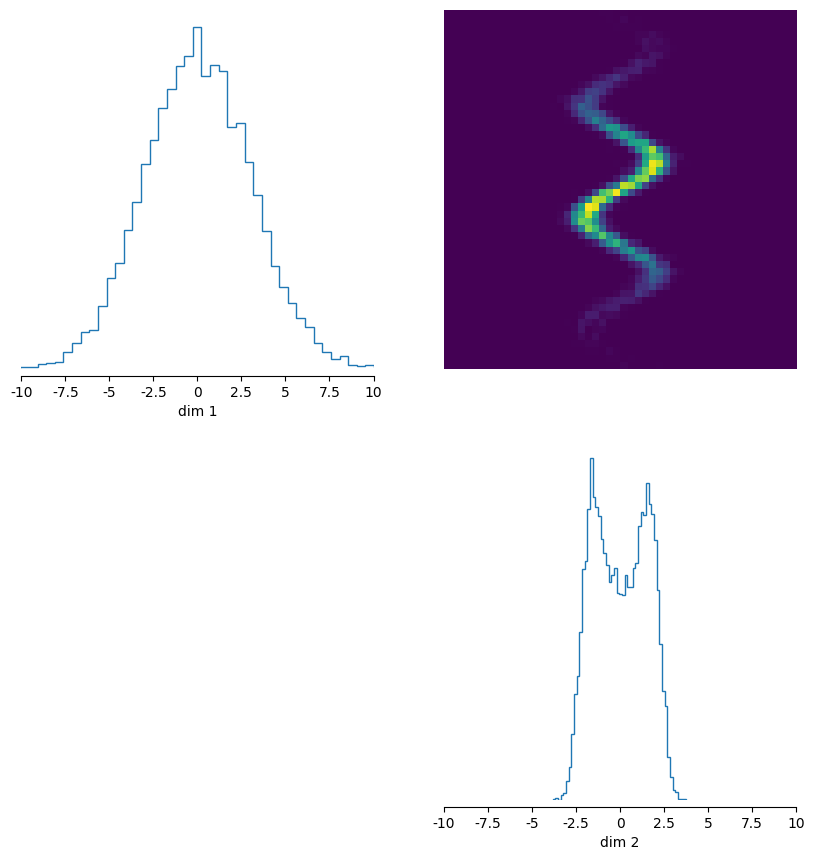

In [4]:
pairplot(np.array(data[:, :, 0]), limits=[[-10, 10], [-10, 10], [-10, 10]])

In [5]:
key = jrandom.PRNGKey(0)

In [57]:
from probjax.nn.bijective import rational_quadratic_spline
from probjax.nn.helpers import rotate, SinusoidalEmbedding

from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution

In [76]:

@jax.vmap
def bijector(params, x):
    return rational_quadratic_spline(params, x, range_min_x=-10, range_max_x=10,range_min_y = -15., range_max_y=15.)

num_bins = 5
bijector_dim = 3 * num_bins 

num_transforms = 3
rotations = [jax.random.orthogonal(jax.random.PRNGKey(i), 2, ()) for i in range(num_transforms-1)]

Array([[ 1., -0.],
       [-0.,  1.]], dtype=float32)

In [77]:

def model(t, x, node_ids, condition_mask, mask=None):
    batch_size, seq_len, node_dim = x.shape
    condition_mask = condition_mask.astype(jnp.int32).reshape(-1,seq_len, 1)
    node_ids = node_ids.reshape(-1,seq_len)
    t = t.reshape(-1,1, 1) / num_transforms
    
    # Embed values and conditions
    dim = 40
    _dim = dim // 2
    embedding_net = hk.nets.MLP([dim, _dim])    # Value embedding net
    embedding_id_nets = hk.Embed(T_max, _dim)   # Node id embedding nets
    embedding_time = SinusoidalEmbedding(_dim)  # Time embedding net
    
    # Conditioning embedding
    condition_embedding = hk.get_parameter("condition_embedding", shape=(1,1,dim), init=hk.initializers.RandomNormal(mean=1.))
    condition_embedding = condition_embedding * condition_mask
    

    # Transformer
    model = Transformer(num_heads=1, num_layers=3, attn_size=20, dropout_rate=0.0, widening_factor=4)

    # Embed inputs and broadcast
    value_embeddings = embedding_net(x)
    id_embeddings = embedding_id_nets(node_ids)
    time_embeddings = embedding_time(t)
    value_embeddings, id_embeddings, time_embeddings = jnp.broadcast_arrays(value_embeddings, id_embeddings, time_embeddings)
    
    # Concatenate embeddings
    x_encoded = jnp.concatenate([value_embeddings, id_embeddings], axis=-1)
    x_encoded = x_encoded + condition_embedding
        

    # Encode
    if mask is None:
        mask = (jnp.eye(seq_len, dtype=jnp.int32) + node_ids[..., :, None] != node_ids[..., None, :]).astype(jnp.bool_)
    h = model(x_encoded, context=time_embeddings, mask=mask)

    # Decode
    out = hk.Linear(bijector_dim)(h)

    out = out * (1-condition_mask)
    return out


In [78]:
init, model_fn = hk.transform(model)

params = init(key, jnp.ones(1), jnp.zeros((10,2,1)), node_ids, jnp.zeros_like(node_ids))
out = model_fn(params, key, jnp.ones(1), jnp.zeros((10,2,1)), node_ids, jnp.zeros_like(node_ids))

In [92]:


def transform(x, params, node_ids, condition_mask):

    bij_params1 = model_fn(params, key, jnp.zeros(1), x.reshape(-1,len(node_ids),1), node_ids, condition_mask)
    bij_params1 = bij_params1.reshape(len(node_ids), bijector_dim)
    y0 = bijector(bij_params1, x)
    y1 = rotate(rotations[0], y0)
    bij_params2 = model_fn(params, key, jnp.ones(1), y1.reshape(-1,len(node_ids),1), node_ids, condition_mask)
    bij_params2 = bij_params2.reshape(len(node_ids), bijector_dim)
    y2 = bijector(bij_params2, y1)
    y3 = rotate(rotations[1], y2)
    bij_params3 = model_fn(params, key, jnp.ones(1)*2, y3.reshape(-1,len(node_ids),1), node_ids, condition_mask)
    bij_params3 = bij_params3.reshape(len(node_ids), bijector_dim)
    y4 = bijector(bij_params3, y3)

    return y4

p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)
p = TransformedDistribution(p0, lambda x: transform(x, params, node_ids, jnp.zeros_like(node_ids)))

samples = p.sample(key, (10,))
log_prob = p.log_prob(samples)

NotImplementedError: Cannot invert a:f32[1,2,40] = dot_general[
  dimension_numbers=(([2], [0]), ([], []))
  preferred_element_type=float32
] b c

In [41]:
from probjax import inver

<function __main__.transform(x, bij_params1, rot1, bij_params2, rot2, bij_params3, rot3, bij_params4)>

In [36]:
f = lambda x: transform(x,node_ids, params)

In [37]:
optimizer = optax.adam(5e-4)
opt_state = optimizer.init(params)

In [48]:
@jax.jit
def loss_fn(params, key, batch_size= 512):

    rng_model, rng_time, rng_sample, rng_data, rng_permute_ids, rng_condition = jax.random.split(key, 6)
    
    # Generate data
    batch_xs = generate_data(rng_data, batch_size) # n, T_max, 1

    # Generate condition mask
    condition_mask = jax.random.choice(rng_condition, jnp.array([[0,0], [1,0], [0,1]]), shape=(1,), p=jnp.array([0.33, 0.33, 0.33]), axis=0)
    condition_mask = condition_mask[..., None]

    # Permute sequence -> randomly permute the sequence of data to promote node identification
    node_values = jnp.zeros_like(batch_xs) + condition_mask * batch_xs

    bij_params = transform_params(node_ids, node_values, params)
    @jax.vmap
    def log_prob_fn(node_values, *bij_params):
        p0 = Independent(Normal(jnp.zeros((2,)), jnp.ones((2,))), 1)
        p = TransformedDistribution(p0, lambda x: transform(x,*bij_params))
        return p.log_prob(jnp.squeeze(batch_xs, -1))
    
    log_prob = log_prob_fn(node_values, *bij_params)
    
    
    loss = -jnp.mean(log_prob)
    return loss


@jax.jit
def update(params, rng, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, rng)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [49]:
# This takes forever to compile ... Probably due to splines with vmap -> Actually no, probably due to transformer also getting transformation as input
_ = update(params, key, opt_state) 

In [51]:
for _ in range(5):
    for i in range(1000):
        key = jrandom.PRNGKey(i+1000)
        loss, params, opt_state = update(params, key, opt_state)
        #if i % 500 == 0:
        print(loss)

4.493683
4.2599816
4.332054


KeyboardInterrupt: 

In [53]:

def sample_fn(key, shape, node_ids=node_ids, condition_mask=jnp.zeros((T_max,), dtype=int), condition_value=jnp.zeros((T_max,))):
    p0 = Independent(Normal(jnp.zeros(2), jnp.ones(2)), 1)
    bij_params = transform_params(node_ids, jnp.zeros_like(node_ids), params)
    p = TransformedDistribution(p0, lambda x: transform(x,*bij_params))
    return p.sample(key, shape)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

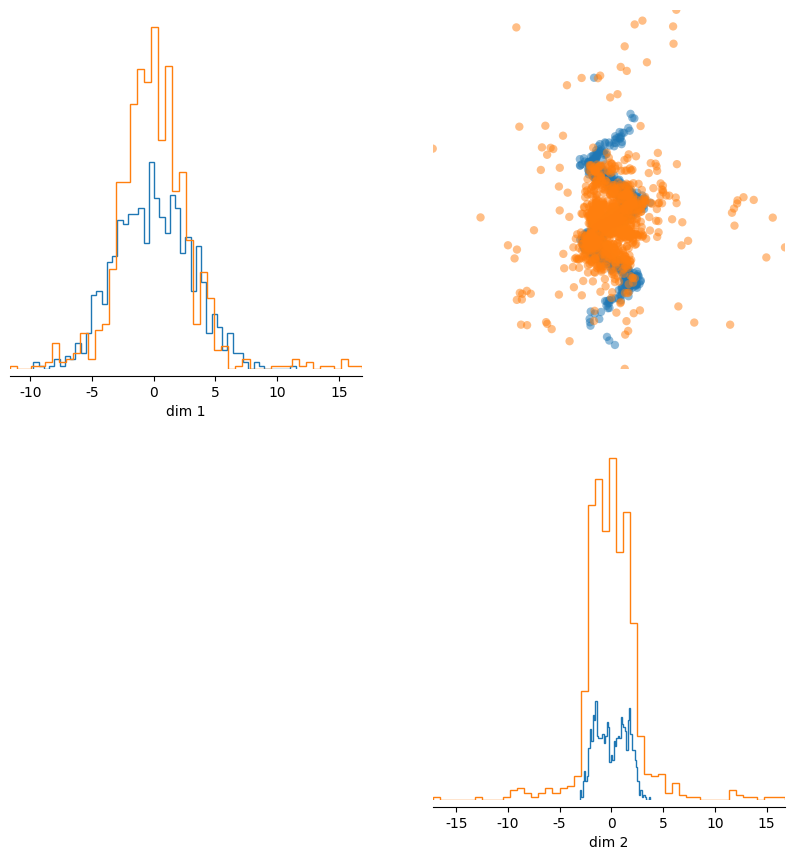

In [54]:

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids)
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,:])], upper="scatter")

2


(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

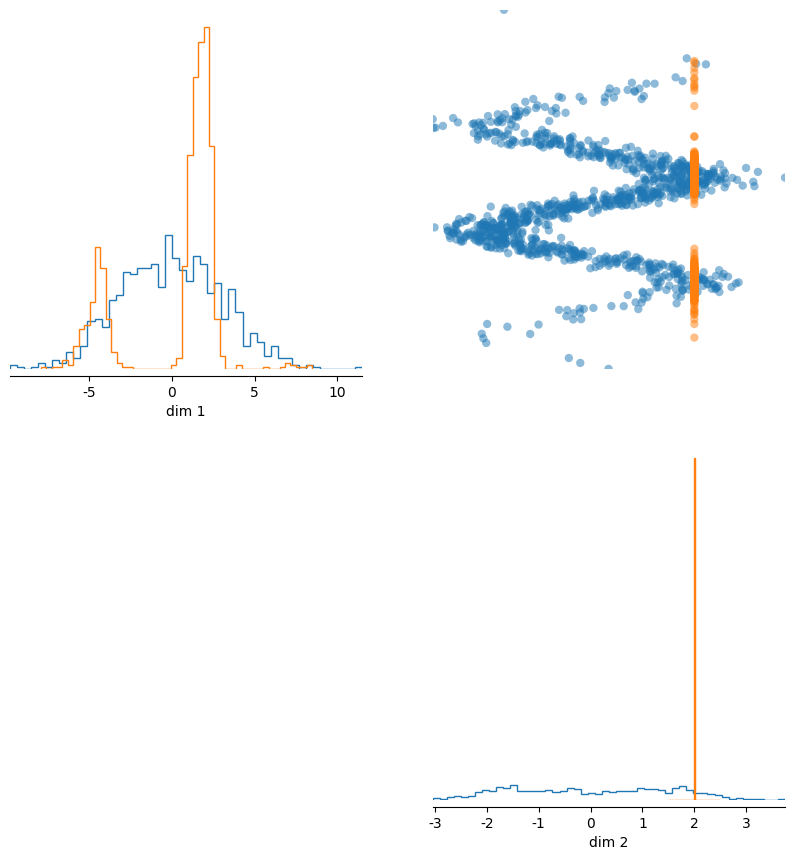

In [72]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

2


(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

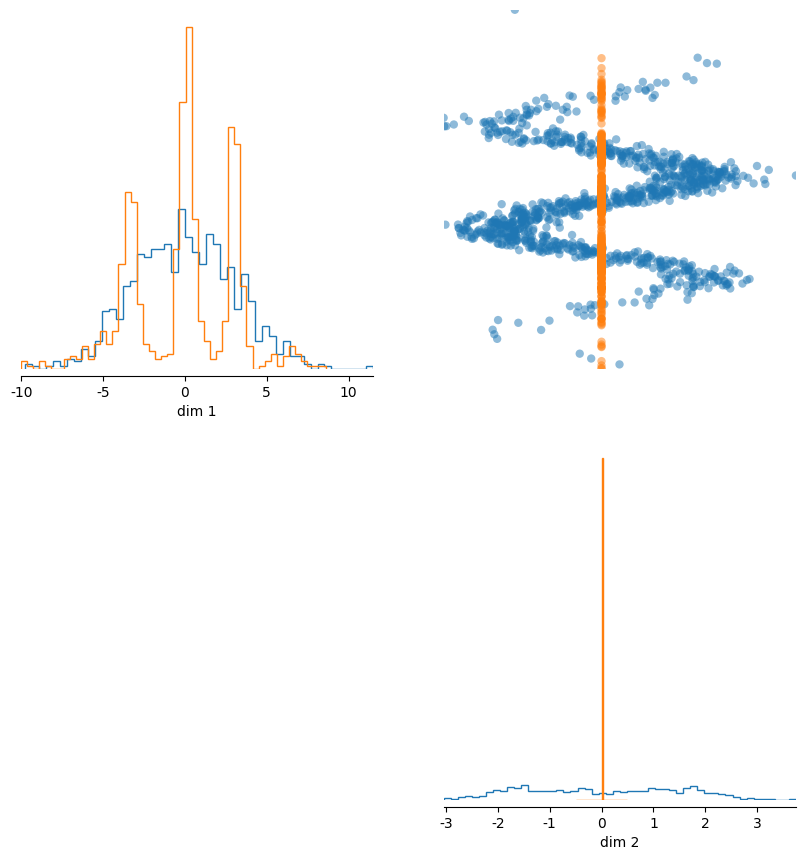

In [73]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([0,1]), condition_value=jnp.array([0., 0.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

2


(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

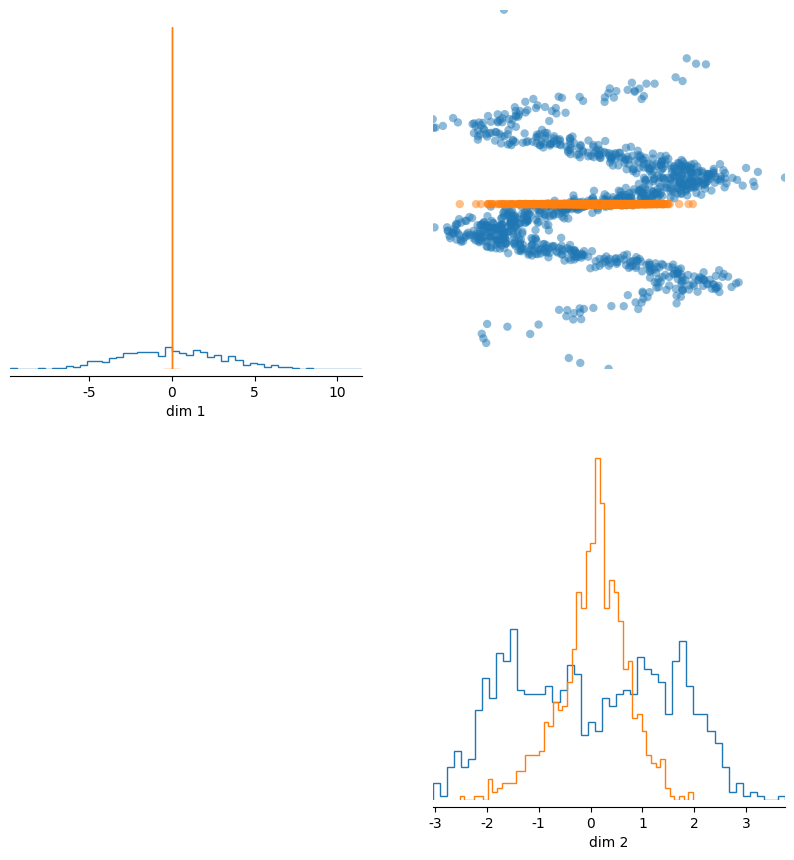

In [74]:
samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=node_ids, condition_mask=jnp.array([1,0]), condition_value=jnp.array([0., 2.]))
pairplot([np.array(data[:1000,:,0]),np.array(samples[...,-1, :])], upper="scatter")

2


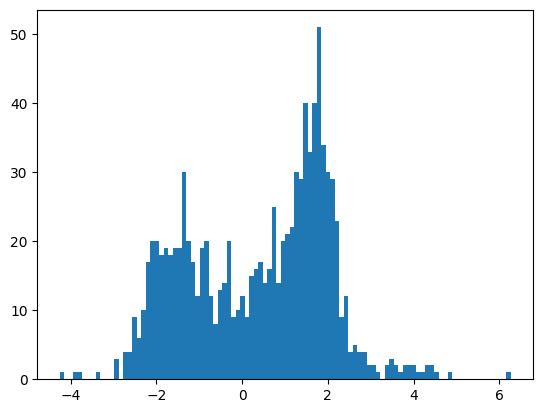

In [225]:
from sbi.analysis import pairplot
import numpy as np
condition_mask = jnp.array([0,0])

samples = sample_fn(jrandom.PRNGKey(0), (1000, ), node_ids=jnp.array([1]))
_ = plt.hist(np.array(samples[...,-1, 1]).flatten(), bins=100)